# Edinburgh Airbnb - Correlation & Driver Analysis

The analysis uses log-transformed price rather than raw price because Airbnb prices are heavily right-skewed and contain several extreme outliers. The transformation reduces skew, limits the influence of unusually expensive listings, and produces a more stable target variable for regression modelling.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from src.modeling.build_star_schema import get_bathroom_column

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/processed/edinburgh/listings_master.csv", low_memory=False)

# reuse the bathroom cleaning logic from the star schema build
df["bathrooms_numeric"] = get_bathroom_column(df)

# recompute distance from the city centre for modeling
CITY_CENTRE_LAT, CITY_CENTRE_LON = 55.9486, -3.1999


def haversine_distance_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


df["distance_from_centre_km"] = haversine_distance_km(
    df["latitude"], df["longitude"], CITY_CENTRE_LAT, CITY_CENTRE_LON
)

print(f"{len(df):,} listings loaded")

4,925 listings loaded


## Correlation matrix

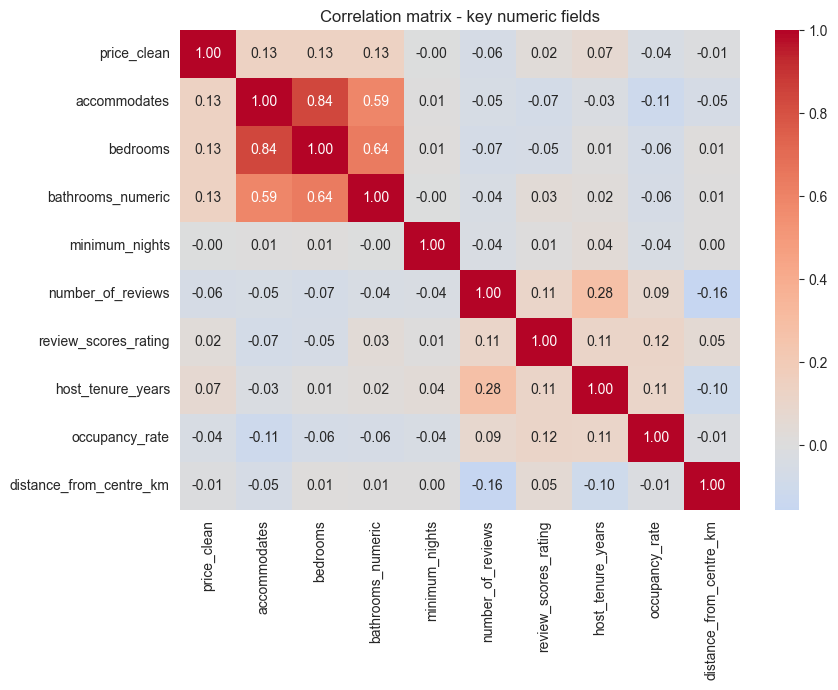

In [7]:
numeric_cols = [
    "price_clean", "accommodates", "bedrooms", "bathrooms_numeric",
    "minimum_nights", "number_of_reviews", "review_scores_rating",
    "host_tenure_years", "occupancy_rate", "distance_from_centre_km",
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix - key numeric fields")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig16_correlation_heatmap.png", dpi=150)
plt.show() 

**Figure 16: Correlation matrix.** Price shows only weak linear relationships with the numeric variables in this dataset. The strongest correlations with price_clean are accommodates, bedrooms, and bathrooms_numeric (all approximately r = 0.13), suggesting that larger properties tend to charge higher prices, although the relationship is much weaker than might be expected. Variables such as review score, occupancy rate, minimum nights, and distance from the city centre have near-zero correlations with price, indicating that none of these factors alone is a strong linear predictor of listing price.

The most notable correlations in the matrix occur between the property-size variables themselves rather than with price. Accommodates and bedrooms are highly correlated (r = 0.84), while both are also strongly correlated with bathrooms_numeric (r = 0.59–0.64). This suggests these variables capture similar aspects of property size and may introduce multicollinearity if included together in a regression model. The VIF analysis that follows is therefore important to determine whether all three variables should remain in the final model.

## Regression - quantifying price drivers

In [4]:
model_cols = [
    "price_clean", "accommodates", "bedrooms", "bathrooms_numeric",
    "review_scores_rating", "minimum_nights", "distance_from_centre_km",
    "room_type", "host_is_superhost",
]
model_df = df[model_cols].dropna()
print(f"{len(model_df):,} listings with complete data for regression (out of {len(df):,} total)")

room_type_dummies = pd.get_dummies(model_df["room_type"], prefix="room", drop_first=True)
X = pd.concat([
    model_df[["accommodates", "bedrooms", "bathrooms_numeric", "review_scores_rating",
              "minimum_nights", "distance_from_centre_km"]],
    room_type_dummies,
    model_df["host_is_superhost"].map({"t": 1, "f": 0}).rename("is_superhost"),
], axis=1)
X = sm.add_constant(X.astype(float))

y = np.log1p(model_df["price_clean"])

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

4,502 listings with complete data for regression (out of 4,925 total)
                            OLS Regression Results                            
Dep. Variable:            price_clean   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     309.8
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:50:55   Log-Likelihood:                -3788.2
No. Observations:                4502   AIC:                             7598.
Df Residuals:                    4491   BIC:                             7669.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

**Regression interpretation.** The model explains 40.8% of the variation in listing prices (R² = 0.408), indicating moderate explanatory power. Significant positive predictors include accommodates (+12.4% per additional guest), bedrooms (+5.5%), bathrooms (+9.4%), and review score (+18.2%), while distance from the city centre is associated with lower prices (-4.8% per kilometre). Relative to entire homes/apartments, hotel rooms, private rooms, and shared rooms are all significantly cheaper, with private rooms showing the largest discount. Minimum nights and superhost status are not statistically significant once other factors are controlled for.

## Multicollinearity check (VIF)

In [5]:
vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)

,feature,VIF
2,bedrooms,3.836911
1,accommodates,3.831893
3,bathrooms_numeric,1.731019
8,room_Private room,1.338585
4,review_scores_rating,1.140075
10,is_superhost,1.127091
6,distance_from_centre_km,1.065462
9,room_Shared room,1.016055
7,room_Hotel room,1.006233
5,minimum_nights,1.001212


**VIF interpretation.** The VIF results do not indicate a serious multicollinearity problem. The highest values are for bedrooms (3.84) and accommodates (3.83), reflecting the expected relationship between property size measures, while `bathrooms_numeric` (1.73) remains well below common concern thresholds. As a rule of thumb, VIF values above 5 are often treated as potentially problematic and values above 10 as a clear issue; none of the predictors in this model approach those levels.

The moderate VIF values for bedrooms and accommodates are consistent with the correlation matrix, where these variables were strongly correlated with one another. However, the overlap is not severe enough to justify removing either variable. Bedrooms, bathrooms, and accommodates each capture slightly different aspects of property size and all remain statistically significant in the regression. Retaining all three therefore provides additional explanatory power without introducing problematic levels of multicollinearity.

## Non-linear relationship check

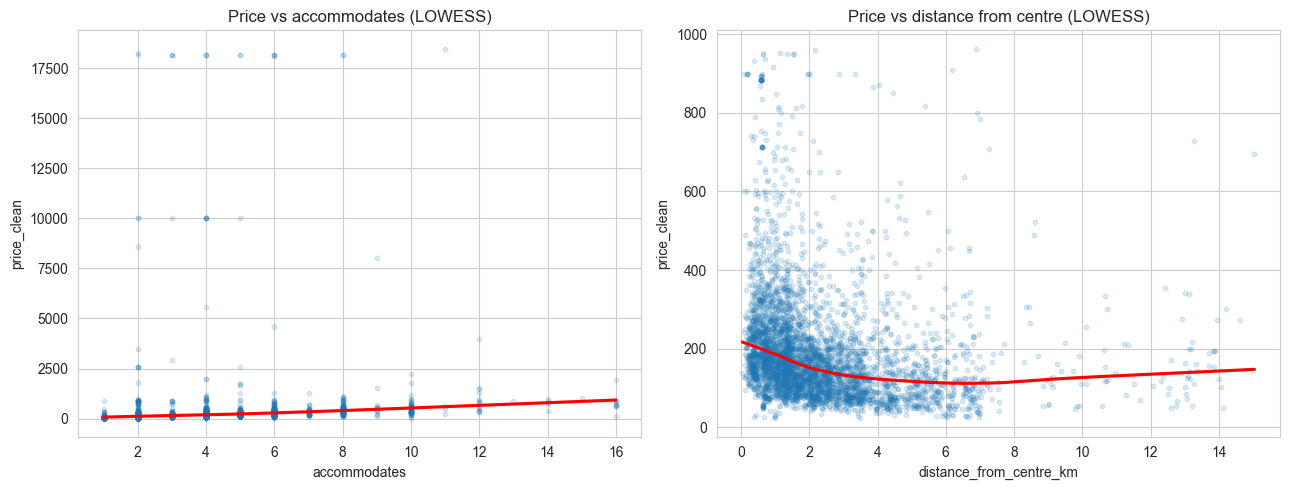

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(
    data=model_df, x="accommodates", y="price_clean", lowess=True,
    scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"}, ax=axes[0],
)
axes[0].set_title("Price vs accommodates (LOWESS)")

sns.regplot(
    data=model_df[model_df["price_clean"] < 1000], x="distance_from_centre_km", y="price_clean",
    lowess=True, scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"}, ax=axes[1],
)
axes[1].set_title("Price vs distance from centre (LOWESS)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig17_price_vs_accommodates_lowess.png", dpi=150)
plt.show()

**Non-linear check.** The relationship between price and accommodates appears broadly positive, but the LOWESS curve suggests some non-linearity. Prices increase steadily as capacity rises, although the rate of increase appears to moderate at higher accommodation counts, indicating that adding extra guest capacity may not generate the same price premium for large properties as it does for smaller ones. This suggests a simple linear term may not fully capture the relationship.

The price versus distance relationship shows even clearer non-linearity. Prices fall sharply within the first few kilometres from the city centre, then flatten considerably, with a slight upward trend at the extreme distances where relatively few listings exist. This indicates that the central-location premium is strongest close to the city centre and weakens further out. These patterns suggest that some pricing relationships are not perfectly linear, providing a rationale for comparing the linear regression model with more flexible approaches such as tree-based models, which can capture non-linear effects without requiring them to be specified explicitly.